# Log Loss (Cross-Entropy Loss)

Loss function for classification that measures how well predicted probabilities match true labels.

**Binary log loss** for a single sample:

$$L = -[y \log(p) + (1-y)\log(1-p)]$$

**Mean log loss** over $n$ samples:

$$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^{n}[y_i \log(p_i) + (1-y_i)\log(1-p_i)]$$

where $y$ = true label (0 or 1), $p$ = predicted probability

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def binary_log_loss(y_true, y_pred):
    """Per-sample binary log loss."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print("Setup complete!")

Setup complete!


## Section 1: Single Prediction Examples

When $y=1$: $L = -\log(p)$ — loss is low when $p$ is close to 1

When $y=0$: $L = -\log(1-p)$ — loss is low when $p$ is close to 0

In [2]:
# All examples: true label y=1, varying predicted probability
examples = [
    (1, 0.95, "Correct, high confidence"),
    (1, 0.51, "Correct, low confidence"),
    (1, 0.05, "Wrong, high confidence"),
    (1, 0.01, "Wrong, extreme confidence"),
]

print(f"{'Scenario':<30} {'y':>3} {'p':>6} {'Loss':>10}")
print("-" * 52)
for y, p, desc in examples:
    loss = binary_log_loss(y, p)
    print(f"{desc:<30} {y:>3} {p:>6.2f} {loss:>10.4f}")

print()
print("Key insight: confident wrong predictions have MUCH higher loss!")

Scenario                         y      p       Loss
----------------------------------------------------
Correct, high confidence         1   0.95     0.0513
Correct, low confidence          1   0.51     0.6733
Wrong, high confidence           1   0.05     2.9957
Wrong, extreme confidence        1   0.01     4.6052

Key insight: confident wrong predictions have MUCH higher loss!


## Section 2: Visualizing Log Loss

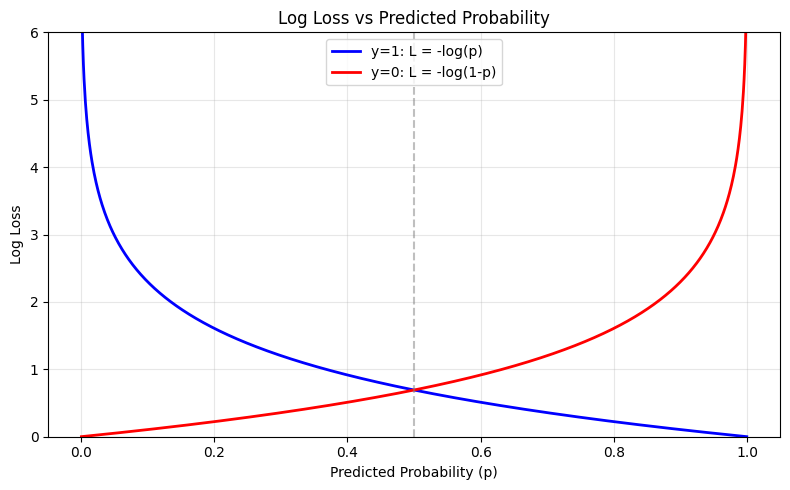

In [3]:
prob = np.linspace(0.001, 0.999, 1000)

plt.figure(figsize=(8, 5))
plt.plot(prob, -np.log(prob), 'b-', linewidth=2, label='y=1: L = -log(p)')
plt.plot(prob, -np.log(1 - prob), 'r-', linewidth=2, label='y=0: L = -log(1-p)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Predicted Probability (p)')
plt.ylabel('Log Loss')
plt.title('Log Loss vs Predicted Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Section 3: Mean Log Loss over Multiple Samples

In [4]:
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 1])
y_pred  = np.array([0.9, 0.2, 0.8, 0.6, 0.3, 0.95, 0.1, 0.7])

losses = binary_log_loss(y_true, y_pred)

print(f"{'Sample':<8} {'y':>4} {'p':>6} {'Loss':>10}")
print("-" * 30)
for i in range(len(y_true)):
    print(f"{i+1:<8} {y_true[i]:>4} {y_pred[i]:>6.2f} {losses[i]:>10.4f}")

print("-" * 30)
print(f"Mean Log Loss: {np.mean(losses):.4f}")

Sample      y      p       Loss
------------------------------
1           1   0.90     0.1054
2           0   0.20     0.2231
3           1   0.80     0.2231
4           1   0.60     0.5108
5           0   0.30     0.3567
6           1   0.95     0.0513
7           0   0.10     0.1054
8           1   0.70     0.3567
------------------------------
Mean Log Loss: 0.2416


## Section 4: Multi-class Log Loss

For $K$ classes, log loss for sample $i$ is simply $-\log(p_{\text{true class}})$

$$\text{Multi-class LogLoss} = -\frac{1}{n}\sum_{i=1}^{n} \log(p_{i, \text{true class}})$$

In [5]:
# 5 samples, 3 classes
y_true_mc = np.array([0, 1, 2, 0, 2])

# Predicted probabilities [class0, class1, class2] for each sample
y_pred_mc = np.array([
    [0.85, 0.10, 0.05],  # Sample 1: predicts class 0 (correct)
    [0.10, 0.80, 0.10],  # Sample 2: predicts class 1 (correct)
    [0.20, 0.30, 0.50],  # Sample 3: predicts class 2 (correct, low confidence)
    [0.60, 0.30, 0.10],  # Sample 4: predicts class 0 (correct)
    [0.10, 0.10, 0.80],  # Sample 5: predicts class 2 (correct)
])

print(f"{'Sample':<8} {'True':>5} {'p(true class)':>14} {'Loss':>10}")
print("-" * 40)
total_loss = 0
for i in range(len(y_true_mc)):
    p_true = y_pred_mc[i, y_true_mc[i]]
    loss = -np.log(p_true)
    total_loss += loss
    print(f"{i+1:<8} {y_true_mc[i]:>5} {p_true:>14.3f} {loss:>10.4f}")

print("-" * 40)
print(f"Mean Multi-class Log Loss: {total_loss / len(y_true_mc):.4f}")

Sample    True  p(true class)       Loss
----------------------------------------
1            0          0.850     0.1625
2            1          0.800     0.2231
3            2          0.500     0.6931
4            0          0.600     0.5108
5            2          0.800     0.2231
----------------------------------------
Mean Multi-class Log Loss: 0.3626


## Section 5: Comparing Models Using Log Loss

Lower log loss = better model. A model that's confidently wrong scores much worse.

In [6]:
y_true = np.array([1, 1, 0, 0, 1, 0, 1, 0])

# Three models with different quality
good_model = np.array([0.9, 0.85, 0.1, 0.15, 0.88, 0.12, 0.92, 0.08])
okay_model = np.array([0.6, 0.55, 0.4, 0.45, 0.58, 0.42, 0.62, 0.38])
bad_model  = np.array([0.1, 0.2, 0.85, 0.9, 0.15, 0.95, 0.05, 0.92])

models = [("Good", good_model), ("Okay", okay_model), ("Bad", bad_model)]

print(f"True labels: {y_true}")
print()
print(f"{'Model':<8} {'Predictions':<45} {'Log Loss':>10}")
print("-" * 65)
for name, preds in models:
    loss = np.mean(binary_log_loss(y_true, preds))
    print(f"{name:<8} {str(preds):<45} {loss:>10.4f}")

print()
print("The bad model (confidently wrong) has ~20x the loss of the good model.")

True labels: [1 1 0 0 1 0 1 0]

Model    Predictions                                     Log Loss
-----------------------------------------------------------------
Good     [0.9  0.85 0.1  0.15 0.88 0.12 0.92 0.08]         0.1198
Okay     [0.6  0.55 0.4  0.45 0.58 0.42 0.62 0.38]         0.5329
Bad      [0.1  0.2  0.85 0.9  0.15 0.95 0.05 0.92]         2.3158

The bad model (confidently wrong) has ~20x the loss of the good model.


## Summary

**Key properties of log loss:**
- Always ≥ 0 (perfect predictions → loss = 0)
- Unbounded — approaches ∞ for confidently wrong predictions
- Heavily penalizes confident misclassifications
- Works for binary and multi-class classification

**Use log loss when:**
- You need probability outputs (not just class labels)
- Training classifiers with gradient descent (logistic regression, neural networks)
- You want to penalize overconfident wrong predictions

**Don't use when:**
- Regression problems → use MSE
- Only class labels matter → use accuracy
- You need bounded loss → use squared loss